<a href="https://colab.research.google.com/github/shadynagy111-eng/Decoding-EGX-Price-Action/blob/CNN_Baseline_Implementation/Resnet50_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
import shutil
from google.colab import drive
from PIL import Image

# ==========================================
# 1. CONFIGURATION & EXPERIMENT SETTINGS
# ==========================================
IMAGE_TYPE = "candlesticks"   # switch to "candlesticks" for second run
EXPERIMENT = "B"          # switch to "B" for second imbalance experiment

DRIVE_BASE_DIR = '/content/drive/MyDrive/AI4Fin'
LOCAL_BASE_DIR = '/content/local_dataset'
RESULTS_DIR = os.path.join(DRIVE_BASE_DIR, 'results')

os.makedirs(RESULTS_DIR, exist_ok=True)

# Mount Google Drive
try:
    drive.mount('/content/drive')
except Exception:
    print("Drive not mounted, continuing.")

# ==========================================
# 2. CLEANUP & COPY/UNZIP DATA TO LOCAL STORAGE
# ==========================================
# Clean up local dataset first as requested
if os.path.exists(LOCAL_BASE_DIR):
    print(f"Deleting existing contents of {LOCAL_BASE_DIR}...")
    shutil.rmtree(LOCAL_BASE_DIR)

# We copy the zip file from Drive to local storage first, then extract to speed up I/O
drive_zip_path = os.path.join(DRIVE_BASE_DIR, f"{IMAGE_TYPE}.zip")
local_zip_path = f"/content/{IMAGE_TYPE}.zip"
local_extract_dir = os.path.join(LOCAL_BASE_DIR, IMAGE_TYPE)

if not os.path.exists(local_extract_dir):
    print(f"Dataset {IMAGE_TYPE} not found locally. Preparing to extract...")

    # 1. Copy zip from Drive to local /content
    if os.path.exists(drive_zip_path):
        print(f"Copying {drive_zip_path} to local storage...")
        shutil.copy2(drive_zip_path, local_zip_path)

        # 2. Extract zip
        print(f"Extracting {local_zip_path} to {local_extract_dir}...")
        os.makedirs(local_extract_dir, exist_ok=True)
        with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
            zip_ref.extractall(local_extract_dir)

        # 3. Clean up the local zip to save space
        os.remove(local_zip_path)
        print("Extraction complete and temporary zip deleted.")
    else:
        print(f"Error: {drive_zip_path} does not exist in your Drive. Please check the path.")
else:
    print(f"Local dataset for {IMAGE_TYPE} already exists at {local_extract_dir}.")

# Paths for the DataLoader
TRAIN_DIR = os.path.join(local_extract_dir, 'train')
VAL_DIR = os.path.join(local_extract_dir, 'val')
TEST_DIR = os.path.join(local_extract_dir, 'test')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Deleting existing contents of /content/local_dataset...
Dataset candlesticks not found locally. Preparing to extract...
Copying /content/drive/MyDrive/AI4Fin/candlesticks.zip to local storage...
Extracting /content/candlesticks.zip to /content/local_dataset/candlesticks...
Extraction complete and temporary zip deleted.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import random
import json
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    cohen_kappa_score, matthews_corrcoef, confusion_matrix, classification_report
)

# ==========================================
# 3. SEEDING FOR REPRODUCIBILITY
# ==========================================
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# ==========================================
# 4. DATASET & DATALOADERS
# ==========================================
import os

BATCH_SIZE = 32
TRAIN_COUNTS = {'Bearish': 4932, 'Bullish': 5617, 'Neutral': 23758}

# Handle potential nested folders from zip extraction
nested_dir_1 = os.path.join(local_extract_dir, IMAGE_TYPE)
nested_dir_2 = os.path.join(local_extract_dir, 'content', IMAGE_TYPE)

if not os.path.exists(TRAIN_DIR):
    if os.path.exists(os.path.join(nested_dir_2, 'train')):
        print(f"Nested directory structure detected (content/{IMAGE_TYPE}). Adjusting paths...")
        TRAIN_DIR = os.path.join(nested_dir_2, 'train')
        VAL_DIR = os.path.join(nested_dir_2, 'val')
        TEST_DIR = os.path.join(nested_dir_2, 'test')
    elif os.path.exists(os.path.join(nested_dir_1, 'train')):
        print(f"Nested directory structure detected ({IMAGE_TYPE}). Adjusting paths...")
        TRAIN_DIR = os.path.join(nested_dir_1, 'train')
        VAL_DIR = os.path.join(nested_dir_1, 'val')
        TEST_DIR = os.path.join(nested_dir_1, 'test')

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(f"Using TRAIN_DIR: {TRAIN_DIR}")
print("Loading datasets...")
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_test_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transform)

# Ensure class mapping is as expected
class_names = train_dataset.classes
print(f"Class mapping: {train_dataset.class_to_idx}")

total_samples = sum(TRAIN_COUNTS.values())

if EXPERIMENT == "A":
    # Exp A: Class weights in Loss Function
    print("Experiment A: Using class weights in loss function.")
    class_weights = [total_samples / (3 * TRAIN_COUNTS[c]) for c in class_names]
    class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

elif EXPERIMENT == "B":
    # Exp B: WeightedRandomSampler
    print("Experiment B: Using WeightedRandomSampler.")
    sample_weights = [1.0 / TRAIN_COUNTS[class_names[label]] for _, label in train_dataset.samples]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_dataset), replacement=True)
    criterion = nn.CrossEntropyLoss() # Unweighted

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")


Nested directory structure detected (content/candlesticks). Adjusting paths...
Using TRAIN_DIR: /content/local_dataset/candlesticks/content/candlesticks/train
Loading datasets...
Class mapping: {'Bearish': 0, 'Bullish': 1, 'Neutral': 2}
Experiment B: Using WeightedRandomSampler.
Train batches: 1073 | Val batches: 151 | Test batches: 279


In [ ]:
# ==========================================
# 5. MODEL ARCHITECTURE
# ==========================================
class AI4FinResNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Load base ResNet50
        base = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

        # Change 1: Preprocessing block
        self.preproc = nn.Sequential(
            nn.Conv2d(3, 3, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU(inplace=True),
        )
        nn.init.kaiming_normal_(self.preproc[0].weight, mode='fan_out', nonlinearity='relu')
        nn.init.constant_(self.preproc[1].weight, 1)
        nn.init.constant_(self.preproc[1].bias, 0)

        # Change 2: Replace conv1 and maxpool
        base.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        nn.init.kaiming_normal_(base.conv1.weight, mode='fan_out', nonlinearity='relu')
        base.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Change 3: Replace final FC
        in_features = base.fc.in_features
        base.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(256, 3),
        )

        self.backbone = base

    def forward(self, x):
        x = self.preproc(x)
        return self.backbone(x)

model = AI4FinResNet().to(DEVICE)

# ==========================================
# 6. LAYER FREEZING STRATEGY
# ==========================================
for name, param in model.backbone.named_parameters():
    if name.startswith('layer2') or name.startswith('layer3'):
        param.requires_grad = False

# Parameter Summary
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {frozen_params:,}")

Trainable parameters: 15,707,802
Frozen parameters: 8,317,952


In [ ]:
# ==========================================
# 7. TRAINING CONFIG & LOOP
# ==========================================
MAX_EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
scaler = torch.amp.GradScaler('cuda') # Added AMP for faster training

best_model_path = os.path.join(RESULTS_DIR, f"{IMAGE_TYPE}_{EXPERIMENT}_best_model.pth")
log_path = os.path.join(RESULTS_DIR, f"{IMAGE_TYPE}_{EXPERIMENT}_training_log.csv")

best_val_f1 = 0.0
patience_counter = 0
early_stop_patience = 10
training_history = []

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for inputs, labels in tqdm(loader, desc="Training", leave=False):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        # Use Automatic Mixed Precision
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, 1)

        # Avoid CPU sync inside the loop by keeping them as tensors temporarily
        all_preds.append(preds.detach())
        all_labels.append(labels.detach())

    epoch_loss = running_loss / len(loader.dataset)

    # Sync to CPU and numpy only once at the end of the epoch
    all_preds = torch.cat(all_preds).cpu().numpy()
    all_labels = torch.cat(all_labels).cpu().numpy()

    _, _, macro_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
    return epoch_loss, macro_f1

def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating", leave=False):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, 1)

            all_preds.append(preds.detach())
            all_labels.append(labels.detach())

    epoch_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds).cpu().numpy()
    all_labels = torch.cat(all_labels).cpu().numpy()

    _, _, macro_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
    return epoch_loss, macro_f1, all_preds, all_labels

# --- MAIN TRAINING LOOP ---
print(f"\nStarting Training: {IMAGE_TYPE} - Experiment {EXPERIMENT}")
for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_f1 = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_f1, _, _ = eval_epoch(model, val_loader, criterion)

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_f1)

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

    training_history.append({
        'epoch': epoch, 'train_loss': train_loss, 'train_f1': train_f1,
        'val_loss': val_loss, 'val_f1': val_f1, 'lr': current_lr
    })

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        print("  -> Saved best model!")
    else:
        patience_counter += 1

    if patience_counter >= early_stop_patience:
        print(f"Early stopping triggered at epoch {epoch}!")
        break

# Save logs
pd.DataFrame(training_history).to_csv(log_path, index=False)



Starting Training: candlesticks - Experiment B


Training:   0%|          | 0/1073 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 01/50 | LR: 1.00e-04 | Train Loss: 1.0865 | Train F1: 0.3665 | Val Loss: 1.1248 | Val F1: 0.3201
  -> Saved best model!


Training:   0%|          | 0/1073 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 13/50 | LR: 5.00e-05 | Train Loss: 0.5466 | Train F1: 0.7623 | Val Loss: 1.3212 | Val F1: 0.3537


Training:   0%|          | 0/1073 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 14/50 | LR: 5.00e-05 | Train Loss: 0.4947 | Train F1: 0.7892 | Val Loss: 1.5311 | Val F1: 0.3500
Early stopping triggered at epoch 14!


Best Val Macro-F1: 0.3567


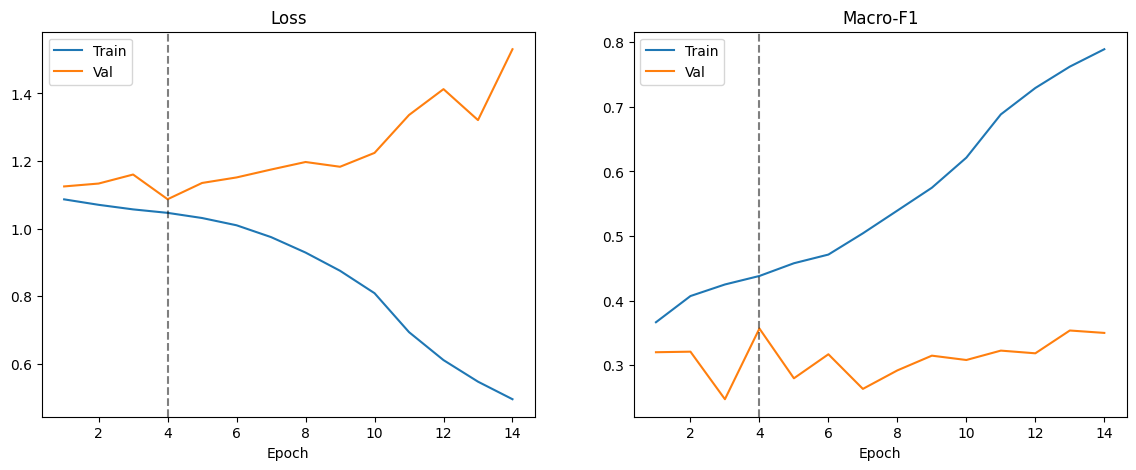

Evaluating:   0%|          | 0/279 [00:00<?, ?it/s]


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     Bearish       0.15      0.10      0.12      1271
     Bullish       0.20      0.36      0.25      1632
     Neutral       0.70      0.59      0.64      5996

    accuracy                           0.48      8899
   macro avg       0.35      0.35      0.34      8899
weighted avg       0.53      0.48      0.50      8899



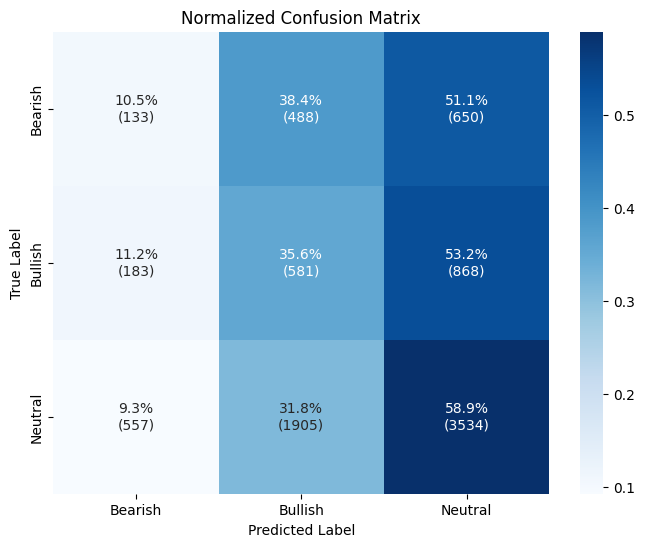

In [ ]:
# ==========================================
# 8. TRAINING CURVES & CLASSIFICATION EVAL
# ==========================================
# Load best model for testing
model.load_state_dict(torch.load(best_model_path))
print(f"Best Val Macro-F1: {best_val_f1:.4f}")

history_df = pd.DataFrame(training_history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train')
ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val')
best_epoch = history_df.loc[history_df['val_f1'].idxmax(), 'epoch']
ax1.axvline(best_epoch, color='k', linestyle='--', alpha=0.5)
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

# F1 plot
ax2.plot(history_df['epoch'], history_df['train_f1'], label='Train')
ax2.plot(history_df['epoch'], history_df['val_f1'], label='Val')
ax2.axvline(best_epoch, color='k', linestyle='--', alpha=0.5)
ax2.set_title('Macro-F1')
ax2.set_xlabel('Epoch')
ax2.legend()

curves_path = os.path.join(RESULTS_DIR, f"{IMAGE_TYPE}_{EXPERIMENT}_training_curves.png")
plt.savefig(curves_path)
plt.show()

# --- TEST EVALUATION ---
_, _, test_preds, test_labels = eval_epoch(model, test_loader, criterion)

acc = accuracy_score(test_labels, test_preds)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(test_labels, test_preds, average='macro', zero_division=0)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(test_labels, test_preds, average='weighted', zero_division=0)
kappa = cohen_kappa_score(test_labels, test_preds)
mcc = matthews_corrcoef(test_labels, test_preds)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(test_labels, test_preds, target_names=class_names, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=np.array([[f"{v:.1%}\n({c})" for v, c in zip(row_norm, row_counts)]
                                           for row_norm, row_counts in zip(cm_normalized, cm)]),
            fmt='', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Normalized Confusion Matrix')
cm_path = os.path.join(RESULTS_DIR, f"{IMAGE_TYPE}_{EXPERIMENT}_confusion_matrix.png")
plt.savefig(cm_path)
plt.show()

pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(RESULTS_DIR, f"{IMAGE_TYPE}_{EXPERIMENT}_confusion_matrix.csv"))

In [ ]:
# ==========================================
# 9. FINANCIAL EVALUATION & SUMMARY TABLE
# ==========================================
meta_path = os.path.join(DRIVE_BASE_DIR, 'dataset_metadata.csv')

if os.path.exists(meta_path):
    meta_df = pd.read_csv(meta_path)

    test_results = []
    for idx, (path, true_label) in enumerate(test_dataset.samples):
        filename = os.path.basename(path)  # e.g. TICKER_STARTROW_ENDROW.png
        # Extract ticker and start_row
        parts = filename.replace('.png', '').split('_')
        if len(parts) >= 2:
            ticker = parts[0]
            try:
                row_start = int(parts[1])
            except ValueError:
                row_start = -1
        else:
            ticker, row_start = "", -1

        pred_idx = test_preds[idx]
        pred_class = class_names[pred_idx]

        # Trading logic mapping: Bearish=0 -> -1, Bullish=1 -> +1, Neutral=2 -> 0
        if pred_class == 'Bullish': pos = 1
        elif pred_class == 'Bearish': pos = -1
        else: pos = 0

        test_results.append({
            'ticker': ticker,
            'window_row_start': row_start,
            'pred_class': pred_class,
            'position': pos
        })

    results_df = pd.DataFrame(test_results)
    # Merge on window_row_start since the filenames use row indices, not dates
    merged = pd.merge(results_df, meta_df, on=['ticker', 'window_row_start'], how='inner')

    merged['trade_return'] = merged['position'] * merged['pct_change']

    total_return = merged['trade_return'].sum()
    mean_ret = merged['trade_return'].mean()
    std_ret = merged['trade_return'].std()

    sharpe = (mean_ret / std_ret) * np.sqrt(252/5) if std_ret > 0 else 0

    merged['cumulative'] = merged['trade_return'].cumsum()
    rolling_max = merged['cumulative'].cummax()
    drawdown = merged['cumulative'] - rolling_max
    max_drawdown = drawdown.min()

    pos_returns = merged[merged['trade_return'] > 0]['trade_return'].sum()
    neg_returns = merged[merged['trade_return'] < 0]['trade_return'].sum()
    profit_factor = pos_returns / abs(neg_returns) if neg_returns != 0 else float('inf')

    trades_taken = merged[merged['trade_return'] != 0]
    win_rate = len(trades_taken[trades_taken['trade_return'] > 0]) / len(trades_taken) if len(trades_taken) > 0 else 0

    unique_tickers = merged['ticker'].nunique()
    baseline_return = merged['pct_change'].sum() / unique_tickers if unique_tickers > 0 else 0

    fin_metrics = {
        'total_return': total_return,
        'sharpe_ratio': sharpe,
        'max_drawdown': max_drawdown,
        'profit_factor': profit_factor,
        'win_rate': win_rate,
        'total_trades': len(trades_taken),
        'baseline_return': baseline_return
    }

    with open(os.path.join(RESULTS_DIR, f"{IMAGE_TYPE}_{EXPERIMENT}_financial_metrics.json"), 'w') as f:
        json.dump(fin_metrics, f, indent=4)
else:
    print("dataset_metadata.csv not found, skipping financial evaluation.")
    fin_metrics = {k: None for k in ['total_return', 'sharpe_ratio', 'max_drawdown', 'profit_factor', 'win_rate', 'total_trades', 'baseline_return']}

# --- SUMMARY TABLE ---
summary_data = {
    'Image Type': IMAGE_TYPE,
    'Experiment': EXPERIMENT,
    'Best Val Macro-F1': best_val_f1,
    'Test Accuracy': acc,
    'Test Macro-F1': macro_f1,
    'Cohen Kappa': kappa,
    'MCC': mcc,
    'Sharpe Ratio': fin_metrics['sharpe_ratio'],
    'Max Drawdown': fin_metrics['max_drawdown'],
    'Profit Factor': fin_metrics['profit_factor'],
    'Win Rate': fin_metrics['win_rate'],
    'Total Trades': fin_metrics['total_trades']
}

summary_df = pd.DataFrame([summary_data])
display(summary_df)

# Append to master CSV
master_csv_path = os.path.join(RESULTS_DIR, 'all_experiments_summary.csv')
if os.path.exists(master_csv_path):
    master_df = pd.read_csv(master_csv_path)
    master_df = pd.concat([master_df, summary_df], ignore_index=True)
else:
    master_df = summary_df

master_df.to_csv(master_csv_path, index=False)
print(f"\nRun completed! Results appended to {master_csv_path}")


,Image Type,Experiment,Best Val Macro-F1,Test Accuracy,Test Macro-F1,Cohen Kappa,MCC,Sharpe Ratio,Max Drawdown,Profit Factor,Win Rate,Total Trades
0,candlesticks,B,0.356741,0.477357,0.3387,0.036053,0.037361,0.203462,-36.716235,1.143366,0.505979,3763



Run completed! Results appended to /content/drive/MyDrive/AI4Fin/results/all_experiments_summary.csv
